In [ ]:
%load_ext autoreload
%autoreload 2

In [284]:
import os
import numpy as np
import uproot
import pandas as pd
from collections import OrderedDict
from common_utils import build_jets
from common_utils import extract_kinematics
from common_utils import get_hadron_kinematics
from common_utils import get_muon_kinematics
import fastjet as fj
import awkward as ak
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
ibu_bins = OrderedDict()
ibu_bins["pT_l1"] = np.asarray([25.0, 125.0, 200.0, 300.0, 400.0, 500.0, 800.0])
ibu_bins["pT_l2"] = np.asarray([25.0, 50.0, 75.0, 100.0, 150.0, 200.0, 400.0])
ibu_bins["eta_l1"] = np.asarray([-2.5, -2.0, -1.5, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5])
ibu_bins["eta_l2"] = np.asarray([-2.5, -2.0, -1.5, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5])
ibu_bins["phi_l1"] = np.asarray([-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)])
ibu_bins["phi_l2"] = np.asarray([-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)])
ibu_bins["pT_trackj1"] = np.asarray([5.0, 50.0, 100.0, 150.0, 200.0, 300.0, 1000.0])
ibu_bins["pT_trackj2"] = np.asarray([5.0, 25.0, 50.0, 100.0, 500.0])
ibu_bins["y_trackj1"] = np.asarray([-2.5, -2.0, -1.75, -1.5, -1.25, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5])
ibu_bins["y_trackj2"] = np.asarray([-2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5])
ibu_bins["phi_trackj1"] = np.asarray([-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)])
ibu_bins["phi_trackj2"] = np.asarray([-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)])
ibu_bins["pT_ll"] = np.asarray([200.0, 230.0, 300.0, 450.0, 600.0, 1000.0])
ibu_bins["y_ll"] = np.asarray([-2.5, -2.0, -1.5, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5])
ibu_bins["Ntracks_trackj1"] = np.asarray([0.5, 6.5, 10.5, 14.5, 19.5, 25.5, 39.5])
ibu_bins["Ntracks_trackj2"] = np.asarray([0.5, 3.5, 7.5, 11.5, 15.5, 34.5])
ibu_bins["m_trackj1"] = np.asarray([0.0, 8.0, 16.0, 24.0, 32.0, 42.0, 70.0])
ibu_bins["m_trackj2"] = np.asarray([0.0, 5.0, 10.0, 20.0, 40.0] )
ibu_bins["tau1_trackj1"] = np.asarray([0.0, 0.05, 0.1, 0.17, 0.25, 0.35, 0.4, 0.9])
ibu_bins["tau1_trackj2"] = np.asarray([0.0, 0.1, 0.2, 0.35, 0.5, 0.9])
ibu_bins["tau2_trackj1"] = np.asarray([0.0, 0.025, 0.05, 0.08, 0.12, 0.17, 0.2, 0.5])
ibu_bins["tau2_trackj2"] = np.asarray([0.0, 0.025, 0.1, 0.17, 0.25, 0.5])
ibu_bins["tau3_trackj1"] = np.asarray([0.0, 0.025, 0.05, 0.1, 0.3])
ibu_bins["tau3_trackj2"] = np.asarray([0.0, 0.025, 0.08, 0.14, 0.3])

plot_labels = {
    "pT_l1"           : r"Leading lepton $p_{\text{T}}$ [GeV]",
    "pT_l2"           : r"Subleading lepton $p_\text{T}$ [GeV]",
    "eta_l1"          : r"Leading lepton $\eta$",
    "eta_l2"          : r"Subleading lepton $\eta$",
    "phi_l1"          : r"Leading lepton $\phi$",
    "phi_l2"          : r"Subleading lepton $\phi$",
    "pT_trackj1"      : r"Leading jet $p_{\text{T}}$ [GeV]",
    "pT_trackj2"      : r"Subleading jet $p_{\text{T}}$ [GeV]",
    "y_trackj1"       : r"Leading jet $y$",
    "y_trackj2"       : r"Subleading jet $y$",
    "phi_trackj1"     : r"Leading jet $\phi$",
    "phi_trackj2"     : r"Subleading jet $\phi$",
    "pT_ll"           : r"Dilepton $p_{\text{T}}$ [GeV]",
    "y_ll"            : r"Dilepton $y$",
    "Ntracks_trackj1" : r"Leading jet $n_\text{ch}$ ",
    "Ntracks_trackj2" : r"Subleading jet $n_\text{ch}$ ",
    "m_trackj1"       : r"Leading jet $m$ [GeV]",
    "m_trackj2"       : r"Subleading jet $m$ [GeV]",
    "tau1_trackj1"    : r"Leading jet $\tau_1$",
    "tau1_trackj2"    : r"Subleading jet $\tau_1$",
    "tau2_trackj1"    : r"Leading jet $\tau_2$",
    "tau2_trackj2"    : r"Subleading jet $\tau_2$",
    "tau3_trackj1"    : r"Leading jet $\tau_3$",
    "tau3_trackj2"    : r"Subleading jet $\tau_3$",
}

labels = {
     'pT_l1' : r'd$\sigma$/d$p_\text{T}^{\mu 1}$ [fb/GeV]',
     'pT_l2' : r'd$\sigma$/d$p_\text{T}^{\mu 2}$ [fb/GeV]',
     'eta_l1' : r'd$\sigma$/d$\eta^{\mu 1}$ [fb]',
     'eta_l2' : r'd$\sigma$/d$\eta^{\mu 2}$ [fb]',
     'phi_l1' : r'd$\sigma$/d$\phi^{\mu 1}$ [fb]',
     'phi_l2' : r'd$\sigma$/d$\phi^{\mu 2}$ [fb]',
     'pT_trackj1' : r'd$\sigma$/d$p_\text{T}$ [fb/GeV]',
     'pT_trackj2' : r'd$\sigma$/d$p_\text{T}$ [fb/GeV]',
     'y_trackj1' : r'd$\sigma$/d$y$ [fb]',
     'y_trackj2' : r'd$\sigma$/d$y$ [fb]',
     'phi_trackj1' : r'd$\sigma$/d$\phi$ [fb]',
     'phi_trackj2' : r'd$\sigma$/d$\phi$ [fb]',
     'pT_ll' : r'd$\sigma$/d$p_\text{T}^{\mu\mu}$ [fb/GeV]',
     'y_ll' : r'd$\sigma$/d$y^{\mu\mu}$ [fb]',
     'Ntracks_trackj1' : r'd$\sigma$/dn$_\text{ch}$ [fb]',
     'Ntracks_trackj2' : r'd$\sigma$/dn$_\text{ch}$ [fb]',
     'm_trackj1' : r'd$\sigma$/d$m$ [fb/GeV]',
     'm_trackj2' : r'd$\sigma$/d$m$ [fb/GeV]',
     'tau1_trackj1' : r'd$\sigma$/d$\tau_1$ [fb]',
     'tau1_trackj2' : r'd$\sigma$/d$\tau_1$ [fb]',
     'tau2_trackj1' : r'd$\sigma$/d$\tau_2$ [fb]',
     'tau2_trackj2' : r'd$\sigma$/d$\tau_2$ [fb]',
     'tau3_trackj1' : r'd$\sigma$/d$\tau_3$ [fb]',
     'tau3_trackj2' : r'd$\sigma$/d$\tau_3$ [fb]',
 }

var_list = ['pT_l1','pT_l2','eta_l1','eta_l2','phi_l1','phi_l2','pT_trackj1','pT_trackj2','y_trackj1','y_trackj2','phi_trackj1','phi_trackj2','pT_ll','y_ll','Ntracks_trackj1','Ntracks_trackj2','m_trackj1','m_trackj2','tau1_trackj1','tau1_trackj2','tau2_trackj1','tau2_trackj2','tau3_trackj1','tau3_trackj2','tau21','dR_ll']

This notebook will runjet building algorithms to produce unfolded data predictions for various variables build using non-standard jet algorith and jet radii. Possible algorithms includs: Cambridge Achan antikT and kT.  

In [412]:
# Load all event data from ROOT files
f_mg = uproot.open("/Applications/PhD/Omni_FIles_Kevin/final_public_data/madgraph_events.root")
t_mg = f_mg["OmniTree"]
truth_pass190 = ak.to_numpy(t_mg["truth_pass190"].array())
truth_pT_ll = ak.to_numpy(t_mg["truth_pT_ll"].array())
truth_pass200 = np.logical_and(truth_pass190, truth_pT_ll > 200)

#madgraph_weights = pd.read_hdf("/Applications/PhD/Omni_FIles_Kevin/final_public_data/madgraph_weights.h5")

# f_pseudodata = uproot.open("/Applications/PhD/Omni_FIles_Kevin/final_public_data/truth_pseudodata_events.root")
# t_pseudodata = f_pseudodata["OmniTree"]

f_hv = uproot.open("/Applications/PhD/Omni_FIles_Kevin/final_public_data/hv_events.root")
t_hv = f_hv["OmniTree"]
truth_pass190_hv = ak.to_numpy(t_hv["truth_pass190"].array())
truth_pT_ll_hv = ak.to_numpy(t_hv["truth_pT_ll"].array())
truth_pass200_hv = np.logical_and(truth_pass190, truth_pT_ll > 200)
print(len(truth_pass200_hv))

# f_sherpa1 = uproot.open("/Applications/PhD/Omni_FIles_Kevin/final_public_data/sherpa/sherpa_events_part1.root")
# t_sherpa1 = f_sherpa1["OmniTree"]

# f_sherpa2 = uproot.open("/Applications/PhD/Omni_FIles_Kevin/final_public_data/sherpa/sherpa_events_part2.root")
# t_sherpa2 = f_sherpa2["OmniTree"]

1035714


In [413]:
# Load event weights for pseudodata measurement


# sherpa_weights1 = pd.read_hdf("/Applications/PhD/Omni_FIles_Kevin/final_public_data/sherpa/sherpa_weights_part1.h5")
# sherpa_weights2 = pd.read_hdf("/Applications/PhD/Omni_FIles_Kevin/final_public_data/sherpa/sherpa_weights_part2.h5")

# truth_pseudodata_weights = pd.read_hdf("/Applications/PhD/Omni_FIles_Kevin/final_public_data/truth_pseudodata_weights.h5")
#truth_pd_weights = { "truthpd": ak.to_numpy(truth_pseudodata_weights["weight_mc"].array())[truth_pass200_pd == 1]}


# Load event weights for Omnifold data measurement. These get attahed to events in madgraph_events.root
data_weights = pd.read_hdf("/Applications/PhD/Omni_FIles_Kevin/final_public_data/data_weights.h5")
data_hv_weights = pd.read_hdf("/Applications/PhD/Omni_FIles_Kevin/final_public_data/data_hv_weights.h5")


# # Load all weights from the Omnifold pseudodata measurement.  These get attahed to events in madgraph_events.root
of_pseudodata = pd.read_hdf( "/Applications/PhD/Omni_FIles_Kevin/final_public_data/pseudodata_weights.h5", key="weights", mode="r",)
of_pseudodata_hv = pd.read_hdf( "/Applications/PhD/Omni_FIles_Kevin/final_public_data/pseudodata_hv_weights.h5", key="hv_weights", mode="r",)


# Create dictionary describing all of the histograms needed for the pseudodata measurement
n_init_weights = [name for name in of_pseudodata.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in of_pseudodata.keys() if "weights_bootstrap_data_" in name]
mcbootstrap_weights = [name for name in of_pseudodata.keys() if "weights_bootstrap_mc_" in name]
truth_mc_weights = {
    # "prior": madgraph_weights["weights_nominal"][truth_pass200 == 1],
    "nominal": of_pseudodata["weights_nominal"].to_numpy()[truth_pass200 == 1],
    **{f"ensemble_{i}": of_pseudodata[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(n_init_weights)},
    **{f"bootstrap_data_{i}": of_pseudodata[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(dbootstrap_weights)},
    **{f"bootstrap_mc_{i}": of_pseudodata[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(mcbootstrap_weights)},
    "trackEffMain": of_pseudodata["weights_trackEffMain"].to_numpy()[truth_pass200 == 1],
    "trackEffJet": of_pseudodata["weights_trackEffJet"].to_numpy()[truth_pass200 == 1],
    "trackFake": of_pseudodata["weights_trackFake"].to_numpy()[truth_pass200 == 1],
    "trackPtScale": of_pseudodata["weights_trackPtScale"].to_numpy()[truth_pass200 == 1],
    "muCalID": of_pseudodata["weights_muCalID"].to_numpy()[truth_pass200 == 1],
    "muCalMS": of_pseudodata["weights_muCalMS"].to_numpy()[truth_pass200 == 1],
    "muCalResBias": of_pseudodata["weights_muCalResBias"].to_numpy()[truth_pass200 == 1],
    "muCalScale": of_pseudodata["weights_muCalScale"].to_numpy()[truth_pass200 == 1],
    "muEffReco": of_pseudodata["weights_muEffReco"].to_numpy()[truth_pass200 == 1],
    "muEffIso": of_pseudodata["weights_muEffIso"].to_numpy()[truth_pass200 == 1],
    "muEffTrack": of_pseudodata["weights_muEffTrack"].to_numpy()[truth_pass200 == 1],
    "muEffTrig": of_pseudodata["weights_muEffTrig"].to_numpy()[truth_pass200 == 1],
    # "pileup": of_pseudodata["weights_pileup"].to_numpy()[truth_pass200 == 1],
    "lumi": of_pseudodata["weights_lumi"].to_numpy()[truth_pass200 == 1],
    "dd": of_pseudodata["weights_dd"].to_numpy()[truth_pass200 == 1],
    "target_dd": of_pseudodata["target_dd"].to_numpy()[truth_pass200 == 1],
}

# hv_weights = { "hv": of_pseudodata_hv["weights_hv"].to_numpy()[truth_pass200_hv == 1] }

In [285]:

algorithm = fj.antikt_algorithm
R = 0.4
n_jobs = 3
if isinstance(t_mg, list):
    all_kinematics = get_hadron_kinematics(t_mg, get_truth=True)

    pt = ak.concatenate([k[0] for k in all_kinematics], axis=0)
    eta = ak.concatenate([k[1] for k in all_kinematics], axis=0)
    phi = ak.concatenate([k[2] for k in all_kinematics], axis=0)
    masses = ak.concatenate([k[3] for k in all_kinematics], axis=0)
else:
    pt, eta, phi, masses = get_hadron_kinematics(t_mg, get_truth=True)

muon_kinematics = get_muon_kinematics(t_mg, get_truth=True)

jets, event_jet_indices = build_jets(
    tree=t_mg,
    pass190_flags=truth_pass200,
    algorithm=algorithm,
    R=R,
    pt=pt,
    eta=eta,
    phi=phi,
    masses=masses,
    n_jobs=n_jobs,
)



Sample kinematics for first event: pt ['43.137352', '39.472950', '34.595486', '26.487041', '23.505688'], eta ['0.300771', '0.315710', '-0.432646', '-1.636316', '0.248256'], phi ['-2.903013', '-2.910223', '2.322683', '3.069867', '-2.967826'], masses ['0.493677', '0.139570', '0.139570', '0.139570', '0.139570']
Preparing 1035714 events for clustering
Processing 1035714 events with 3 jobs


Clustering events:   0%|          | 1020/1035714 [00:00<03:20, 5151.58event/s]

#--------------------------------------------------------------------------
#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#--------------------------------------------------------------------------
#                         FastJet release #                         FastJet release #                 M. Cacciari, G.P. Salam and G. Soyez                  
3.5.1#     A software package for jet finding and analysis at colliders      

#                           https://fastjet.fr                           
#	                                                                      
3.5.1# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package

# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#                                                                       
#     A software package for jet finding an

Clustering events: 100%|██████████| 1035714/1035714 [04:35<00:00, 3755.90event/s]


In [453]:
import numpy as np
import re
import ast
import operator
import time 

def eval_jet_expressions(jets, expressions, nevents=-1):
    """
    Evaluate multiple arithmetic expressions involving jet info fields (INFO_trackj#) in one pass,
    propagating -99 for missing jets, with progress output every 10%.
    Fully vectorized for speed.
    """
    print("Processing expressions:" + ", ".join(expressions) + f" for {nevents if nevents > 0 else len(jets)} events")
    field_map = {"pT":0, "y":1, "phi":2, "m":3}
    nevents = len(jets) if nevents < 0 else min(len(jets), nevents)
    
    # Gather all unique jet tokens across all expressions
    token_pattern = r"\b(\w+_trackj\d+)\b"
    tokens = set()
    for expr in expressions:
        tokens.update(re.findall(token_pattern, expr))
    
    # Build token arrays in a single loop
    print(f"Extracting jet info for tokens: {', '.join(tokens)}")
    token_arrays = {tok: np.full(nevents, -99.0, dtype=float) for tok in tokens}
    progress_step = max(nevents // 10, 1)

    for i, event in enumerate(jets[:nevents]):
        for tok in tokens:
            match = re.match(r"(\w+)_trackj(\d+)", tok)
            field_name, jet_num = match.groups()
            idx = field_map[field_name]
            jet_idx = int(jet_num) - 1
            if len(event) > jet_idx:
                token_arrays[tok][i] = event[jet_idx][idx]
        if (i + 1) % progress_step == 0 or i == nevents - 1:
            print(f"Processed {i+1}/{nevents} events ({100*(i+1)/nevents:.0f}%)", end='\r')
    print("\nFinished extracting jet info for all tokens.")
    
    # Allowed operators
    allowed_ops = {
        ast.Add: operator.add,
        ast.Sub: operator.sub,
        ast.Mult: operator.mul,
        ast.Div: operator.truediv,
        ast.USub: operator.neg,
        ast.UAdd: operator.pos
    }

    def _eval_vectorized(node):
        """ Recursively evaluate AST node for all events at once """
        if isinstance(node, ast.Expression):
            return _eval_vectorized(node.body)
        elif isinstance(node, ast.BinOp):
            left, left_mask = _eval_vectorized(node.left)
            right, right_mask = _eval_vectorized(node.right)
            combined_mask = left_mask | right_mask
            result = np.where(combined_mask, -99.0, allowed_ops[type(node.op)](left, right))
            return result, combined_mask
        elif isinstance(node, ast.UnaryOp):
            val, mask = _eval_vectorized(node.operand)
            result = np.where(mask, -99.0, allowed_ops[type(node.op)](val))
            return result, mask
        elif isinstance(node, ast.Name):
            if node.id not in token_arrays:
                raise ValueError(f"Unknown token: {node.id}")
            arr = token_arrays[node.id]
            mask = (arr == -99)
            return arr, mask
        elif isinstance(node, ast.Constant):
            return np.full(nevents, node.value), np.zeros(nevents, dtype=bool)
        elif hasattr(ast, "Num") and isinstance(node, ast.Num):  # for Python <3.8
            return np.full(nevents, node.n), np.zeros(nevents, dtype=bool)
        else:
            raise ValueError(f"Unsupported element: {node}")

    # Evaluate all expressions **vectorized**
    results = np.full((nevents, len(expressions)), -99.0, dtype=float)
    print(f"Evaluating {len(expressions)} expressions for {nevents} events...")
    for j, expr in enumerate(expressions):
        node = ast.parse(expr, mode='eval')
        val, _ = _eval_vectorized(node)
        results[:, j] = val
        if (j + 1) % max(1, len(expressions)//10) == 0 or j == len(expressions)-1:
            print(f"Processed {j+1}/{len(expressions)} expressions ({100*(j+1)/len(expressions):.0f}%)")
    
    print("Finished evaluating all expressions.")
    return results

In [7]:
expr_list = [
    "m_trackj1",
    "pT_trackj1",
    "pT_trackj1 / m_trackj1",
]
start_time = time.time()
results = eval_jet_expressions(jets, expr_list, nevents=-1)
elapsed = time.time() - start_time
print(f"Total runtime: {elapsed:.2f} seconds")
print("Shape:", results.shape)  # (500, 4)
print("First event:", results[0])

Processing expressions:m_j1, pT_j1, pT_j1 / m_j1 for 1035714 events
Extracting jet info for tokens: pT_j1, m_j1
Processed 1035714/1035714 events (100%)
Finished extracting jet info for all tokens.
Evaluating 3 expressions for 1035714 events...
Processed 1/3 expressions (33%)
Processed 2/3 expressions (67%)
Processed 3/3 expressions (100%)
Finished evaluating all expressions.
Total runtime: 150.20 seconds
Shape: (1035714, 3)
First event: [ 31.43959853 183.05859617   5.82254878]


In [8]:
data_weights = pd.read_hdf("/Applications/PhD/Omni_FIles_Kevin/final_public_data/data_weights.h5")
weights      = data_weights["weights_nominal"]
m_j1         = ak.to_numpy(t_mg["truth_m_trackj1"].array())
pT_j1        = ak.to_numpy(t_mg["truth_pT_trackj1"].array())
pT_j2        = ak.to_numpy(t_mg["truth_pT_trackj2"].array())
m_j2         = ak.to_numpy(t_mg["truth_m_trackj2"].array())

Index: 92380, m_j1_built: 34.410475764097995, m_j1: 36.32768630981445, diff: 1.9172105457164577
Index: 206491, m_j1_built: 0.0005106655892548644, m_j1: 0.6456093192100525, diff: 0.6450986536207977
Index: 522451, m_j1_built: 0.0005085489505130343, m_j1: 0.5185927748680115, diff: 0.5180842259174985
Index: 536953, m_j1_built: 0.0005096536644460319, m_j1: 0.7926103472709656, diff: 0.7921006936065196
Index: 608478, m_j1_built: 0.0005090536052609774, m_j1: 0.6915214657783508, diff: 0.6910124121730898
Index: 655648, m_j1_built: 0.0005120497671041444, m_j1: 0.7633134126663208, diff: 0.7628013628992166
Index: 846120, m_j1_built: 6.120188639831879, m_j1: 7.950953006744385, diff: 1.830764366912506
Index: 891268, m_j1_built: 16.708841785361574, m_j1: 14.861376762390137, diff: 1.8474650229714378


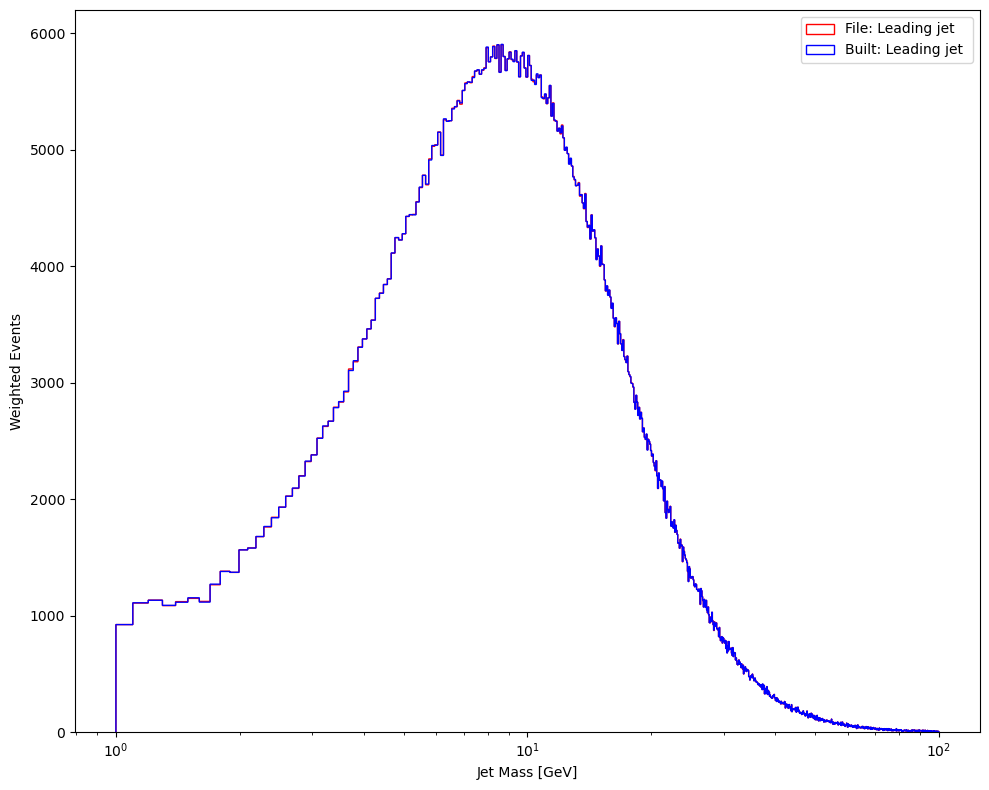

In [9]:
import matplotlib.pyplot as plt

bins = np.linspace(1,100,1000)
m_j1_built = results[:, 0]  # m_j1 from the file
pT_j1_built = results[:, 1]  # pT_j1 from the file
pT_j1_div_m_j1_built = results[:, 2]  # pT_j1 / m_j1


# pT_j1_div_m_j1_file = pT_j1 / m_j1  # pT_j1 / m_j1 from the file
# pT_j1_div_m_j1_file = pT_j1_div_m_j1_file[:100000]

# m_j1 = m_j1[:1000000]
# weights = weights[:1000000]

diff = np.abs(m_j1_built - m_j1)
indices = np.where((diff > 0.2) & (m_j1>0.5))[0]
for idx in indices:
    print(f"Index: {idx}, m_j1_built: {m_j1_built[idx]}, m_j1: {m_j1[idx]}, diff: {diff[idx]}")

plt.figure(figsize=(10,8))
plt.hist(m_j1_built, bins=bins, histtype="step", label="Built: Leading jet ", color="blue")


# plt.hist(m1, bins=bins, weights=weights, histtype="step", label="Leading jet (indecies)")
# plt.hist(m2, bins=bins, weights=weights, histtype="step", label="Subleading jet (m2)")
# plt.hist(m3, bins=bins, weights=weights, histtype="step", label="3rd jet (m3)")
# plt.hist(m4, bins=bins, weights=weights, histtype="step", label="4th jet (m4)")

plt.xlabel("Jet Mass [GeV]")
plt.ylabel("Weighted Events")
plt.legend()
plt.xscale("log")
plt.tight_layout()
plt.show()

In [10]:
import awkward as ak
import numpy as np

def tprofile(x, y, w, bins):

    nbins = len(bins) - 1

    # compute bin indices
    inds = np.digitize(x, bins) - 1

    # keep only valid bins
    mask = (inds >= 0) & (inds < nbins)
    inds = inds[mask]
    y = y[mask]
    w = w[mask]

    # accumulate sums
    sum_w   = np.bincount(inds, weights=w, minlength=nbins)
    sum_wy  = np.bincount(inds, weights=w*y, minlength=nbins)
    sum_wy2 = np.bincount(inds, weights=w*y*y, minlength=nbins)

    # compute profile
    mean = sum_wy / sum_w
    variance = (sum_wy2 / sum_w) - mean**2
    error = np.sqrt(variance / sum_w)

    return mean, error, sum_w

In [11]:
mean, error, sum_w  = tprofile(pT_j1, pT_j1_div_m_j1_built, weights, ibu_bins["pT_trackj1"])

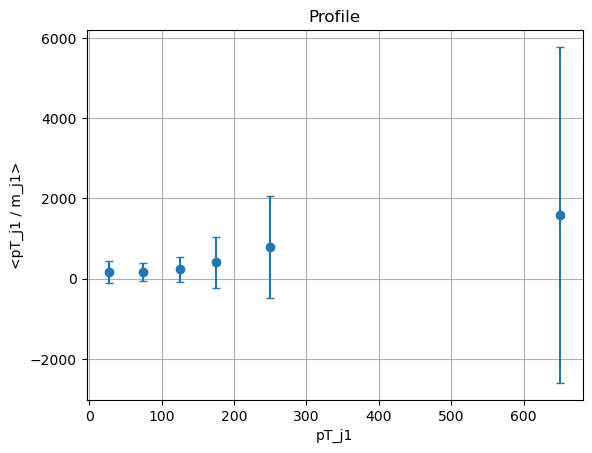

In [12]:
bins = ibu_bins["pT_trackj1"]
bin_centers = 0.5 * (bins[:-1] + bins[1:])

plt.errorbar(
    bin_centers,
    mean,
    yerr=error,
    fmt="o",
    capsize=3
)

plt.xlabel("pT_j1")
plt.ylabel("<pT_j1 / m_j1>")
plt.title("Profile")
plt.grid(True)

plt.show()

In [244]:
import numpy as np
import numba as nb
import awkward as ak

# ------------------------------
# Numba inner loop (per event)
# ------------------------------
@nb.njit
def _profile_event(tracks_pt, tracks_eta, tracks_phi, tracks_mass,
                   event_jet_indices, jets, annulus_edges,
                   compute_psi, only_leading_jet, only_associated,
                   jet_pt_range, jet_y_max, use_rho_old):
    
    pi              = np.pi
    n_bins          = len(annulus_edges) - 1
    rho_sum         = np.zeros(n_bins)
    psi_sum         = np.zeros(n_bins)
    n_selected_jets = 0
    
    # precompute annulus normalization
    if use_rho_old:
        annulus_norm = annulus_edges[1:] - annulus_edges[:-1]
    else:
        annulus_norm = np.pi * (annulus_edges[1:]**2 - annulus_edges[:-1]**2)

    n_tracks = tracks_pt.shape[0]

    for jidx in range(jets.shape[0]):
        jet_pt, jet_y, jet_phi, jet_mass = jets[jidx]

        # Only leading jet if requested
        if only_leading_jet and jidx != 0:
            continue

        # Jet kinematic cuts
        if jet_pt_range is not None and (jet_pt < jet_pt_range[0] or jet_pt > jet_pt_range[1]):
            continue
        if jet_y_max is not None and abs(jet_y) > jet_y_max:
            continue
        
        n_selected_jets += 1

        # Track selection depending on only_associated
        if only_associated:
            mask = np.zeros(n_tracks, dtype=np.bool_)
            for t in range(n_tracks):
                if event_jet_indices[t] == jidx:
                    mask[t] = True
        else:
            mask = np.ones(n_tracks, dtype=np.bool_)

        n_selected = np.sum(mask)
        if n_selected == 0:
            continue

        # select tracks
        pt   = tracks_pt[mask]
        eta  = tracks_eta[mask]
        phi  = tracks_phi[mask]
        mass = tracks_mass[mask]

        # compute 4-vectors
        px = pt * np.cos(phi)
        py = pt * np.sin(phi)
        pz = pt * np.sinh(eta)
        E  = np.sqrt(px**2 + py**2 + pz**2 + mass**2)
        y  = 0.5 * np.log((E + pz) / (E - pz))

        # radial distance
        dphi = (phi - jet_phi + pi) % (2*pi) - pi
        dy   = y - jet_y 
        dR   = np.sqrt(dy**2 + dphi**2)

        # bin indices
        bin_idx = np.empty(pt.shape[0], dtype=np.int64)
        for i in range(pt.shape[0]):
            # np.digitize behavior
            b = 0
            while b < n_bins and dR[i] >= annulus_edges[b+1]:
                b += 1
            bin_idx[i] = b
        # select valid bins
        valid_mask = (bin_idx >= 0) & (bin_idx < n_bins)
        if np.sum(valid_mask) == 0:
            continue

        bin_idx = bin_idx[valid_mask]
        px_sel = px[valid_mask]
        py_sel = py[valid_mask]

        # vector sum per bin
        px_sum = np.zeros(n_bins)
        py_sum = np.zeros(n_bins)
        for i in range(bin_idx.shape[0]):
            px_sum[bin_idx[i]] += px_sel[i]
            py_sum[bin_idx[i]] += py_sel[i]

        pt_vec = np.sqrt(px_sum**2 + py_sum**2)
        
        # compute either rho or psi
        if compute_psi:
            px_cumulative = np.zeros(n_bins)
            py_cumulative = np.zeros(n_bins)
            pt_cumulative = np.zeros(n_bins)
            for i in range(n_bins):
                if i == 0:
                    px_cumulative[i] = px_sum[i]
                    py_cumulative[i] = py_sum[i]
                else:
                    px_cumulative[i] = px_cumulative[i-1] + px_sum[i]
                    py_cumulative[i] = py_cumulative[i-1] + py_sum[i]
                pt_cumulative[i] = np.sqrt(px_cumulative[i]**2 + py_cumulative[i]**2)
            psi_sum += pt_cumulative / jet_pt
        else:
            if use_rho_old:
                rho_sum += pt_vec / (annulus_norm * jet_pt)
            else:
                rho_sum += pt_vec / annulus_norm
    return (psi_sum if compute_psi else rho_sum), n_selected_jets

# ------------------------------
# Outer loop over events (awkward arrays)
# ------------------------------
def jet_radial_profile(jets, event_jet_indices,
                       track_pt, track_eta, track_phi, track_mass,
                       annulus_edges,
                       event_weights,
                       only_associated=True,
                       jet_pt_range=None,
                       jet_y_max=None,
                       use_rho_old=False,
                       compute_psi=False,
                       only_leading_jet=False,
                       max_events=-1):

    event_weights = np.asarray(event_weights)

    # allow single weight vector
    if event_weights.ndim == 1:
        event_weights = event_weights[None, :]

    n_weight_sets = event_weights.shape[0]

    n_events = len(event_jet_indices)
    if max_events > 0:
        n_events = min(n_events, max_events)

    annulus_edges = np.asarray(annulus_edges)
    n_bins = len(annulus_edges) - 1

    total_profile = np.zeros((n_weight_sets, n_bins))
    n_jets_counter = np.zeros(n_weight_sets)

    next_progress = 0.1

    for ievt in range(n_events):

        frac = (ievt + 1) / n_events
        if frac >= next_progress:
            print(f"{int(next_progress*100)}% complete ({ievt+1}/{n_events} events)", flush=True)
            next_progress += 0.1

        # convert jagged arrays
        t_pt     = np.asarray(ak.to_numpy(track_pt[ievt]))
        t_eta    = np.asarray(ak.to_numpy(track_eta[ievt]))
        t_phi    = np.asarray(ak.to_numpy(track_phi[ievt]))
        t_mass   = np.asarray(ak.to_numpy(track_mass[ievt]))
        evt_jets = np.asarray(ak.to_numpy(jets[ievt]))
        indices  = np.asarray(ak.to_numpy(event_jet_indices[ievt]), dtype=np.int64)

        if len(evt_jets) == 0:
            continue

        profile_evt, n_jets = _profile_event(
            t_pt, t_eta, t_phi, t_mass,
            indices, evt_jets, annulus_edges,
            compute_psi, only_leading_jet,
            only_associated, jet_pt_range,
            jet_y_max, use_rho_old
        )

        for iw in range(n_weight_sets):
            w = event_weights[iw, ievt]
            n_jets_counter[iw] += n_jets * w
            total_profile[iw]  += profile_evt * w

    total_profile /= n_jets_counter[:, None]

    return total_profile

In [248]:

r_edges   = np.array([0,0.025,0.05,0.075,0.1,0.125,0.15,0.175,0.2,0.225,0.25,0.275,0.3,0.325,0.35,0.375,0.4])
r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
results  = jet_radial_profile(
    jets              = jets, 
    event_jet_indices = event_jet_indices,
    track_pt          = pt, track_eta=eta, track_phi=phi, track_mass=masses,
    annulus_edges     = r_edges,
    event_weights     = [weights],
    only_associated   = True,
    jet_pt_range      = np.array([150,160]),
    jet_y_max         = 2,
    use_rho_old       = True,
    compute_psi       = False,
    only_leading_jet  = True,
    max_events        = 10000,
)


10% complete (1000/10000 events)
20% complete (2000/10000 events)
30% complete (3001/10000 events)
40% complete (4000/10000 events)
50% complete (5000/10000 events)
60% complete (6000/10000 events)
70% complete (7000/10000 events)
80% complete (8000/10000 events)
89% complete (9000/10000 events)
99% complete (10000/10000 events)


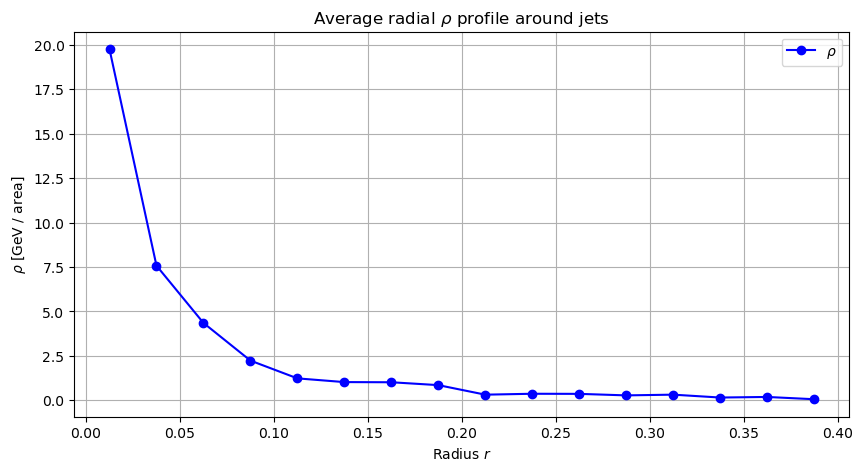

In [249]:
import matplotlib.pyplot as plt
# Create figure
plt.figure(figsize=(10,5))

# Plot rho
plt.plot(r_centers, results[0], marker='o', linestyle='-', color='blue', label=r'$\rho$')
plt.xlabel("Radius $r$")
plt.ylabel(r"$\rho$ [GeV / area]")
plt.title("Average radial $\\rho$ profile around jets")
plt.grid(True)
#plt.yscale("log")
plt.legend()

plt.show()

In [385]:
def count_jets(jets, weights, individual_jet_selection, leading_jet_only=False):

    if leading_jet_only:
        leading = ak.firsts(jets)  # None if event has no jets

        pt  = leading[:, 0]
        y   = leading[:, 1]
        phi = leading[:, 2]
        m   = leading[:, 3]

        mask = individual_jet_selection(pt, y, phi, m)

        # None → False
        njets_pass = ak.fill_none(mask, False)

    else:
        pt  = jets[:, :, 0]
        y   = jets[:, :, 1]
        phi = jets[:, :, 2]
        m   = jets[:, :, 3]

        mask = individual_jet_selection(pt, y, phi, m)

        # count jets per event
        njets_pass = ak.sum(mask, axis=1)

    weights = np.asarray(weights)

    if weights.ndim == 1:
        return float(ak.sum(njets_pass * weights))

    return np.array([float(ak.sum(njets_pass * w)) for w in weights])


In [389]:
def individual_jet_selection(pt, y, phi, m):
    return (pt > 10) & (abs(y) < 2)

nJets = count_jets(jets, weights, individual_jet_selection)
print(nJets)

nLeadingJets = count_jets(jets, weights, individual_jet_selection, leading_jet_only = True)
print(nLeadingJets)



4142.891821166617
1635.4075235109517


In [478]:
expr_list = [
    "m_trackj1",
]
jet_expression = eval_jet_expressions(jets, expr_list, nevents=-1)

Processing expressions:m_trackj1 for 1035714 events
Extracting jet info for tokens: m_trackj1
Processed 1035714/1035714 events (100%)
Finished extracting jet info for all tokens.
Evaluating 1 expressions for 1035714 events...
Processed 1/1 expressions (100%)
Finished evaluating all expressions.


In [490]:
import numpy as np
import awkward as ak

def hist_with_uncertainty(data, bins, obs, weights_dict):
    """
    data : ak.Array or np.ndarray, shape (N,) or (N,M)
    bins : bin edges or list of bin edges
    weights_dict : dict of arrays 
    """

    # Convert Awkward Array to NumPy
    for idx in range(data.shape[1]):
            

      data_obs  = data[:, idx]
      binning   = bins[obs[idx]]
      nominal_w = weights_dict["nominal"]


      # Identify weight groups
      ensemble = [k for k in weights_dict if k.startswith("ensemble_")]
      bootstrap_mc = [k for k in weights_dict if k.startswith("bootstrap_mc_")]
      bootstrap_data = [k for k in weights_dict if k.startswith("bootstrap_data_")]
      
      special = set(["nominal"] + ensemble + bootstrap_mc + bootstrap_data)
      syst_weights = [k for k in weights_dict if k not in special]
      
      hists = []
      uncs = []
      
      hist_nom, _ = np.histogram(data_obs, bins=binning, weights=nominal_w)
      unc2 = np.zeros_like(hist_nom, dtype=float)
      
      # systematics
      for name in syst_weights:
          w = weights_dict[name]
          hist_var, _ = np.histogram(data_obs, bins=binning, weights=w)
          unc2 += (hist_nom - hist_var)**2
      
          # replica uncertainties
          def replica_unc(keys):
              if not keys:
                  return 0
              h = []
              for k in keys:
                  w = weights_dict[k]
                  hist, _ = np.histogram(data_obs, bins=binning, weights=w)
                  h.append(hist)
              return np.std(np.stack(h), axis=0)**2
          
          unc2 += replica_unc(ensemble)
          unc2 += replica_unc(bootstrap_mc)
          unc2 += replica_unc(bootstrap_data)
          
          hists.append(hist_nom)
          uncs.append(np.sqrt(unc2))
      
    return hists, uncs

In [491]:
print(jet_expression.shape)  # should be (n_events, n_expressions)
print(truth_mc_weights["nominal"].shape)  # should be (n_events,) 
nom_omni_results = hist_with_uncertainty(
    data=jet_expression,     # dict-like or dataframe containing variables
    weights_dict=truth_mc_weights,
    obs = ["m_trackj1"],
    bins=ibu_bins
)


(1035714, 1)
(1035714,)


In [ ]:
fig = plt.figure(figsize=(15,20), dpi=300, constrained_layout=True)
subfigs = fig.subfigures(6, 4)

for i, subfig in enumerate(tqdm(subfigs.flat, desc="Plots")):  
    axs = subfig.subplots(2, 1, sharex=True, sharey=False, gridspec_kw = {'height_ratios':[3, 1]})
    var = list(bins_dict.items())[i][0]
    bins = np.array(list(bins_dict.items())[i][1])
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_widths = np.array([bins[n+1] - bins[n] for n in range(len(bins)-1)])
    
    if "trackj1" in var: 
        df = multifold[mask_trackj1]
    elif "trackj2" in var:
        df = multifold[mask_trackj2]
    else:
        df = multifold    
    
    ### Sherpa
    counts = mc_preds[i]['sherpa_counts']
    sherpa_density = counts/lumi/bin_widths
    sherpa_error = mc_preds[i]['sherpa_err']/mc_preds[i]['sherpa_counts']
    _ = make_error_boxes(axs[0], bin_centers, sherpa_density, np.vstack([bin_widths/2,bin_widths/2]), np.vstack([sherpa_density*sherpa_error, sherpa_density*sherpa_error]), facecolor='deeppink', alpha=0.25, marker="s", label=r'Sherpa',)
    
    ### MGFxFx 
    counts = mc_preds[i]['mgfxfx_counts']
    mgfxfx_density = counts/lumi/bin_widths
    mgfxfx_error = mc_preds[i]['mgfxfx_err']/mc_preds[i]['mgfxfx_counts']
    _ = make_error_boxes(axs[0], bin_centers, mgfxfx_density, np.vstack([bin_widths/2,bin_widths/2]), np.vstack([mgfxfx_density*mgfxfx_error, mgfxfx_density*mgfxfx_error]), facecolor='dodgerblue', alpha=0.25, marker="^", label=r'MadGraph')

    ### MultiFold
    multifold_density, _, _ = axs[0].hist(df[var], weights=df.weights_nominal, bins=bins, color='black', linewidth= 2, density=True, alpha=0)
    multifold_density *= np.sum(df.weights_nominal)
    
    axs[0].minorticks_on()
    axs[1].minorticks_on()
    axs[0].xaxis.set_tick_params(labelsize=12, which='both', direction='in', top=True)
    axs[0].yaxis.set_tick_params(labelsize=12, which='both', direction='in', right=True)
    axs[0].set_ylabel(labels[var], fontsize=12, labelpad=2, loc='top')
    axs[0].set_ylim([0, 1.7 * max(max(mgfxfx_density), max(multifold_density))])
    
    ### Set some plots to use log y scale
    if 'phi' not in var and 'eta' not in var and 'y' not in var:
        axs[0].set_yscale('log')
        axs[0].set_ylim([0.5*min(min(sherpa_density), min(multifold_density)), 10 * max(max(sherpa_density), max(multifold_density))])
    
    elif 'phi' in var:
        axs[0].set_ylim(0,600)

    axs[0].errorbar(bin_centers, multifold_density, xerr=bin_widths/2, yerr=multifold_density*uncertainties[var+"_total"]/100, marker=".", linestyle="None", color="k", alpha=1, ecolor='k', label="MultiFold Data", markersize=4, linewidth=1)
    axs[0].legend(fontsize=10, frameon=False, loc='best');
    axs[1].errorbar(bin_centers, np.ones(len(bin_centers)), xerr=bin_widths/2, yerr=uncertainties[var+"_total"]/100, marker=".", linestyle="None", color="k", alpha=1,  ecolor='k', label="MultiFold Data", markersize=4, linewidth=1)
    _ = make_error_boxes(axs[1], bin_centers, sherpa_density/multifold_density, np.vstack([bin_widths/2,bin_widths/2]), np.vstack([(sherpa_density/multifold_density)*sherpa_error, (sherpa_density/multifold_density)*sherpa_error]), facecolor='deeppink', alpha=0.25, marker="s", label=r'Sherpa')
    _ = make_error_boxes(axs[1], bin_centers, mgfxfx_density/multifold_density, np.vstack([bin_widths/2,bin_widths/2]), np.vstack([(mgfxfx_density/multifold_density)*mgfxfx_error, (mgfxfx_density/multifold_density)*mgfxfx_error]), facecolor='dodgerblue', alpha=0.25, marker="^", label=r'MadGraph')
    axs[1].set_xlim(bins[0], bins[-1])
    axs[1].set_ylim([0.2,1.8])
    axs[1].xaxis.set_tick_params(labelsize=12, which='both', direction='in', top=True)
    axs[1].yaxis.set_tick_params(labelsize=12, which='both', direction='in', right=True)
    axs[1].set_ylabel('MC/Data', fontsize=12, labelpad=2, loc='center')
    axs[1].set_xlabel(plot_labels[var], fontsize=16, labelpad=2, loc='right');
    
plt.savefig(os.path.join(plot_dir,"nominal_diff_xsec.pdf"))

In [ ]:
def plot_variable_panel(
    subfig,
    i,
    var,
    bins,
    mc_preds,
    multifold,
    bins_dict,
    labels,
    plot_labels,
    uncertainties,
    lumi,
    mask_trackj1,
    mask_trackj2
):

    axs = subfig.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios':[3,1]})

    bins = np.array(bins)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_widths = bins[1:] - bins[:-1]

    # dataset selection
    if "trackj1" in var:
        df = multifold[mask_trackj1]
    elif "trackj2" in var:
        df = multifold[mask_trackj2]
    else:
        df = multifold

    ### Sherpa
    counts = mc_preds[i]['sherpa_counts']
    sherpa_density = counts / lumi / bin_widths
    sherpa_error = mc_preds[i]['sherpa_err'] / mc_preds[i]['sherpa_counts']

    make_error_boxes(
        axs[0],
        bin_centers,
        sherpa_density,
        np.vstack([bin_widths/2, bin_widths/2]),
        np.vstack([sherpa_density*sherpa_error, sherpa_density*sherpa_error]),
        facecolor='deeppink',
        alpha=0.25,
        marker="s",
        label='Sherpa'
    )

    ### MGFxFx
    counts = mc_preds[i]['mgfxfx_counts']
    mgfxfx_density = counts / lumi / bin_widths
    mgfxfx_error = mc_preds[i]['mgfxfx_err'] / mc_preds[i]['mgfxfx_counts']

    make_error_boxes(
        axs[0],
        bin_centers,
        mgfxfx_density,
        np.vstack([bin_widths/2, bin_widths/2]),
        np.vstack([mgfxfx_density*mgfxfx_error, mgfxfx_density*mgfxfx_error]),
        facecolor='dodgerblue',
        alpha=0.25,
        marker="^",
        label='MadGraph'
    )

    ### MultiFold
    multifold_density, _, _ = axs[0].hist(
        df[var],
        weights=df.weights_nominal,
        bins=bins,
        color='black',
        linewidth=2,
        density=True,
        alpha=0
    )

    multifold_density *= np.sum(df.weights_nominal)

    axs[0].errorbar(
        bin_centers,
        multifold_density,
        xerr=bin_widths/2,
        yerr=multifold_density * uncertainties[var+"_total"] / 100,
        marker=".",
        linestyle="None",
        color="k",
        markersize=4,
        linewidth=1,
        label="MultiFold Data"
    )

    ### Styling
    axs[0].set_ylabel(labels[var])
    axs[1].set_xlabel(plot_labels[var])
    axs[1].set_ylabel("MC/Data")

    axs[0].legend(frameon=False)

    ### Ratio
    axs[1].errorbar(
        bin_centers,
        np.ones(len(bin_centers)),
        xerr=bin_widths/2,
        yerr=uncertainties[var+"_total"]/100,
        marker=".",
        linestyle="None",
        color="k"
    )

    make_error_boxes(
        axs[1],
        bin_centers,
        sherpa_density/multifold_density,
        np.vstack([bin_widths/2,bin_widths/2]),
        np.vstack([
            (sherpa_density/multifold_density)*sherpa_error,
            (sherpa_density/multifold_density)*sherpa_error
        ]),
        facecolor='deeppink',
        alpha=0.25
    )

    make_error_boxes(
        axs[1],
        bin_centers,
        mgfxfx_density/multifold_density,
        np.vstack([bin_widths/2,bin_widths/2]),
        np.vstack([
            (mgfxfx_density/multifold_density)*mgfxfx_error,
            (mgfxfx_density/multifold_density)*mgfxfx_error
        ]),
        facecolor='dodgerblue',
        alpha=0.25
    )

In [ ]:
fig = plt.figure(figsize=(22,11), dpi=300, constrained_layout=True)
subfigs = fig.subfigures(4, 6)

for i, subfig in enumerate(subfigs.flat):
    ax = subfig.subplots(1, 1)
    colors = [plt.cm.Paired(i) for i in range(20)]
    var = list(bins_dict.items())[i][0]
    bins = np.array(list(bins_dict.items())[i][1])

    ax.step(bins, np.concatenate([[uncertainties[var+'_exp'][0]],uncertainties[var+'_exp']]),              label = "Experimental",       color=colors[0],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_theory'][0]],uncertainties[var+'_theory']]),        label = "Theory",             color=colors[1],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_mc_stat'][0]],uncertainties[var+'_mc_stat']]),      label = "MC Stat. + NN",      color=colors[2],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_data_stat'][0]],uncertainties[var+'_data_stat']]),  label = "Data Stat.",         color=colors[3],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_unfolding'][0]],uncertainties[var+'_unfolding']]),  label = "Unfolding",          color=colors[4]     )
    ax.step(bins, np.concatenate([[uncertainties[var+'_top'][0]],uncertainties[var+'_top']]),              label = "Top",                color=colors[5],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_nonDY'][0]],uncertainties[var+'_nonDY']]),          label = r"EW $Zjj$ + $ZV$",   color=colors[6],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_total'][0]],uncertainties[var+'_total']]),          label = "Total",              color='black',      )

    ### draw lines at the beginning and end of the first and last bins, for plotting purposes
    label_list = ['exp', 'theory', 'mc_stat', 'data_stat', 'unfolding', 'top', 'nonDY', 'total']
    for label in label_list:
        plt.vlines(x=bins[0], ymin=0, ymax=uncertainties[var+'_'+label][0])
        plt.vlines(x=bins[-1], ymin=0, ymax=uncertainties[var+'_'+label][-1])

    ax.xaxis.set_tick_params(labelsize=12)
    ax.yaxis.set_tick_params(labelsize=12)
    if i % 6 == 0: ax.set_ylabel("Fractional Uncertainty [\%]", fontsize=12)
    ax.legend(fontsize=9, loc='upper left', ncol=2, frameon=False)
    ax.set_xlim([bins[0], bins[-1]])
    ax.set_ylim([0, 25])
    ax.set_xlabel(plot_labels[var], fontsize=14);
    
plt.savefig(os.path.join(plot_dir,"total_systs.pdf"))